In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar

Problem parameters

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

n = 0.5
mu = 6.0
p = 2.0 / (1.0 - n)

def mu_star(n):
    return np.sqrt(2.0 * (n + 1.0)) / (1.0 - n)

ms = mu_star(n)

print(f"n={n}, mu={mu}, p={p:.6f}, mu*={ms:.6f}")

n=0.5, mu=6.0, p=4.000000, mu*=3.464102


PINN model

In [4]:
class FreeBoundaryPINN(nn.Module):
    def __init__(self, width=64, depth=4):
        super().__init__()

        layers = [nn.Linear(1, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)

        self.xdz_param = nn.Parameter(torch.tensor([0.0], dtype=torch.float64))
        self.eps = 1e-4

    @property
    def xdz(self):
        return torch.sigmoid(self.xdz_param) * (1.0 - self.eps)

    def forward(self, xi):
        M = self.net(xi)                      
        B = 1.0 + (1.0 - xi) * M                 
        u = (xi ** p) * (B ** 2)      
        return u

Physics loss

In [5]:
def physics_loss(model, xi):
    xi = xi.clone().detach().requires_grad_(True)

    xdz = model.xdz
    L = 1.0 - xdz  

    u = model(xi)

    dudxi = torch.autograd.grad(u, xi, torch.ones_like(u), create_graph=True)[0]
    d2udxi2 = torch.autograd.grad(dudxi, xi, torch.ones_like(dudxi), create_graph=True)[0]

    # chain rule
    u_xx = d2udxi2 / (L ** 2)

    # PDE on live zone
    res = u_xx - (mu ** 2) * (u ** n)
    return torch.mean(res ** 2)

Sampling

In [6]:
def sample_xi(N, bias_power=3.0):
    Nu = N // 2
    Nb = N - Nu
    xi_u = torch.rand(Nu, 1, device=device)
    xi_b = torch.rand(Nb, 1, device=device) ** bias_power
    return torch.cat([xi_u, xi_b], dim=0)

Train

In [7]:
model = FreeBoundaryPINN().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=500, factor=0.5)

for epoch in range(10001):
    xi_train = sample_xi(2000, bias_power=4.0)

    opt.zero_grad()
    loss = physics_loss(model, xi_train)
    loss.backward()
    opt.step()
    sched.step(loss)

    if epoch % 500 == 0:
        print(f"epoch {epoch:5d} | loss {loss.item():.3e} | x_dz {model.xdz.item():.6f}")
use_lbfgs = True
if use_lbfgs:
    lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=500, line_search_fn="strong_wolfe")

    def closure():
        lbfgs.zero_grad()
        xi_train = sample_xi(4000, bias_power=5.0)
        l = physics_loss(model, xi_train)
        l.backward()
        return l

    lbfgs.step(closure)
    print(f"after LBFGS | x_dz {model.xdz.item():.6f}")

c:\ProgramData\anaconda3\Lib\site-packages\torch\optim\lr_scheduler.py:1343: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  current = float(metrics)


epoch     0 | loss 1.658e+01 | x_dz 0.499700
epoch   500 | loss 7.894e-02 | x_dz 0.466129
epoch  1000 | loss 1.565e-02 | x_dz 0.453796
epoch  1500 | loss 5.519e-03 | x_dz 0.446806
epoch  2000 | loss 2.385e-03 | x_dz 0.442008
epoch  2500 | loss 3.230e-03 | x_dz 0.438571
epoch  3000 | loss 6.711e-04 | x_dz 0.435874
epoch  3500 | loss 1.519e-02 | x_dz 0.433602
epoch  4000 | loss 1.881e-04 | x_dz 0.431682
epoch  4500 | loss 1.320e-04 | x_dz 0.430222
epoch  5000 | loss 8.109e-05 | x_dz 0.429036
epoch  5500 | loss 4.208e-05 | x_dz 0.427929
epoch  6000 | loss 2.848e-05 | x_dz 0.426957
epoch  6500 | loss 1.667e-05 | x_dz 0.426255
epoch  7000 | loss 1.145e-05 | x_dz 0.425651
epoch  7500 | loss 7.119e-06 | x_dz 0.425146
epoch  8000 | loss 4.187e-06 | x_dz 0.424687
epoch  8500 | loss 2.403e-05 | x_dz 0.424355
epoch  9000 | loss 2.016e-06 | x_dz 0.424066
epoch  9500 | loss 2.176e-06 | x_dz 0.423853
epoch 10000 | loss 2.613e-04 | x_dz 0.423659
after LBFGS | x_dz 0.423677


Reference solutions for plotting and validation

In [8]:
def analytical_free_boundary(x, mu, n):
    ms = mu_star(n)
    if mu <= ms:
        return None, 0.0
    xdz = 1.0 - ms / mu
    p = 2.0 / (1.0 - n)
    u = np.zeros_like(x)
    mask = x > xdz
    xi = (x[mask] - xdz) / (1.0 - xdz)
    u[mask] = xi ** p
    return u, xdz

def numeric_full_domain(x, mu, n):
    def solve_for_a(a):
        def rhs(t, y):
            u, v = y
            return [v, (mu**2) * (max(u, 0.0) ** n)]
        sol = solve_ivp(rhs, [0.0, 1.0], [a, 0.0], t_eval=[1.0], rtol=1e-9, atol=1e-9)
        return sol.y[0, -1] - 1.0
    a_lo, a_hi = 1e-8, 5.0
    f_lo = solve_for_a(a_lo)
    f_hi = solve_for_a(a_hi)
    while f_lo * f_hi > 0:
        a_hi *= 2.0
        f_hi = solve_for_a(a_hi)
        if a_hi > 1e6:
            raise RuntimeError("Failed to bracket shooting parameter a.")

    root = root_scalar(solve_for_a, bracket=[a_lo, a_hi], method="brentq", xtol=1e-12)
    a_star = root.root

    def rhs(t, y):
        u, v = y
        return [v, (mu**2) * (max(u, 0.0) ** n)]

    sol = solve_ivp(rhs, [0.0, 1.0], [a_star, 0.0], t_eval=x, rtol=1e-9, atol=1e-9)
    return sol.y[0], 0.0

PINN evaluation and plotting

Learned x_dz = 0.423677
Reference x_dz=0.422650 | L2 error=1.148e-06


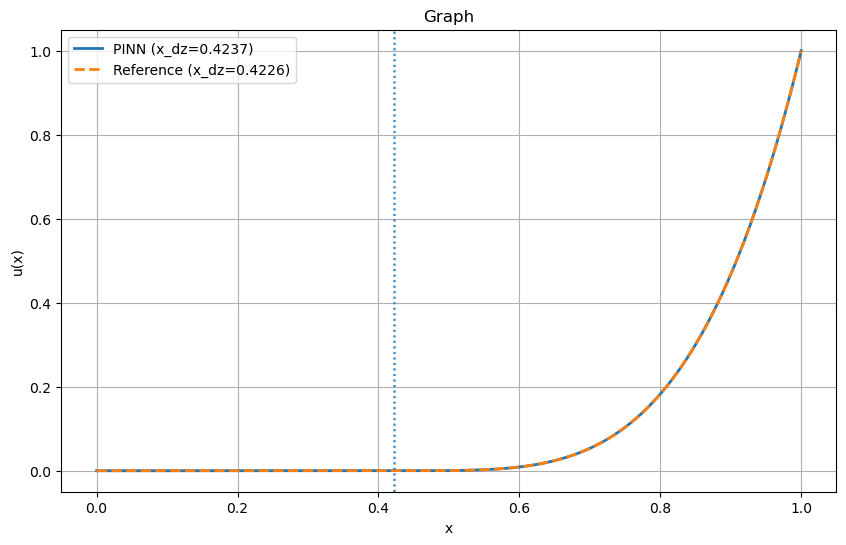

In [9]:
model.eval()
xdz_learned = model.xdz.item()
print(f"Learned x_dz = {xdz_learned:.6f}")

# PINN curve on [0,1]
x_dead = np.linspace(0.0, xdz_learned, 200)
u_dead = np.zeros_like(x_dead)

xi_eval = torch.linspace(0, 1, 600, device=device).view(-1, 1)
with torch.no_grad():
    u_live = model(xi_eval).cpu().numpy().reshape(-1)
x_live = xdz_learned + (1.0 - xdz_learned) * xi_eval.cpu().numpy().reshape(-1)

x_pinn = np.concatenate([x_dead, x_live])
u_pinn = np.concatenate([u_dead, u_live])

# Reference
x_ref = np.linspace(0.0, 1.0, 1200)
u_ref, xdz_ref = analytical_free_boundary(x_ref, mu, n)
if u_ref is None:
    u_ref, xdz_ref = numeric_full_domain(x_ref, mu, n)

# L2 error (on [0,1])
u_pinn_interp = np.interp(x_ref, x_pinn, u_pinn)
L2 = np.sqrt(trapezoid((u_pinn_interp - u_ref) ** 2, x_ref))
print(f"Reference x_dz={xdz_ref:.6f} | L2 error={L2:.3e}")

plt.figure(figsize=(10, 6))
plt.plot(x_pinn, u_pinn, lw=2, label=f"PINN (x_dz={xdz_learned:.4f})")
plt.plot(x_ref, u_ref, "--", lw=2, label=f"Reference (x_dz={xdz_ref:.4f})")
plt.axvline(xdz_learned, ls=":", alpha=0.6)
plt.axvline(xdz_ref, ls=":", alpha=0.6)
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("Graph")
plt.grid(True)
plt.legend()
plt.show()